In [1]:
# R script for phyloGWAS
# author: Sheng-Kai Hsu
# date created: 2023.06.16
# data last edited: 2023.08.01


In [2]:
rm(list=ls())
library(limma)
library(ape)
library(parallel)
library(pheatmap)
library(BGLR)

In [3]:
source("/workdir/sh2246/p_evolBNI/src/S01_phyloK.R")

In [5]:
# load sample metadata
metadata=read.csv("/workdir/sh2246/p_evolBNI/data/BNITaxa_translateTable.csv",header = T)
metadata$Sample=strsplit2(metadata$genome_path,split = "_|.final|.fa")[,1]
metadata$spTaxa=paste0(metadata$Plant_ID,": ",metadata$species.name)


In [19]:
# load and process phenotypic data
dat=read.csv("/workdir/sh2246/p_evolBNI/data/Cornell_PNRandNitrateAssay.csv",header = T)
annualSp=c("Zea mays","Sorghum bicolor","Thelepogon elegans")

#BNI calculation
dat$taxa=strsplit2(dat$plantID_repl.,"_")[,1]
control=median(dat$PNR[dat$taxa=="blank"])
dat$spTaxa=paste0(dat$taxa,": ",dat$species.name)
dat$BNI=(1-dat$PNR/control)*100

#Nitrate conversion
dat$soilN_mgN=dat$soilN*0.005/(0.002*(1-dat$SoilMoisture_dw*dat$DSW/dat$FSW))
dat$resinN_mgN=dat$resinN*0.005/0.002

dat_N_std=c(7.871,7.834,8.024,
            1.4,1.424,1.382,
            0.675,0.66,0.664)

#filtering
head(dat)
dim(dat)
dat_filtered=dat[dat$inTree!=0&dat$condition!=0&!dat$plantID%in%c("A10260002","A10280002","A10310002"),]
dim(dat_filtered)

,Jar.,plantID,Rep,plantID_repl.,label,FSW,SoilMoisture_dw,DSW,PNR,species.name,⋯,T1,T2,T3,condition,inTree,taxa,spTaxa,BNI,soilN_mgN,resinN_mgN
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,21,A11090002,1,A11090002_1,BNI037,5.14,0.878,2.737,2.124303,Andropogon burmanicus,⋯,36.09,1.184,0.199,1,1,A11090002,A11090002: Andropogon burmanicus,-27.186262,7.526196,1.7625
2,71,A11090002,2,A11090002_2,BNI133,5.01,0.745,2.871,1.576033,Andropogon burmanicus,⋯,65.70,0.837,0.261,1,1,A11090002,A11090002: Andropogon burmanicus,5.639777,10.037956,0.9675
3,122,A11090002,3,A11090002_3,BNI066,5.01,0.912,2.621,1.490444,Andropogon burmanicus,⋯,36.97,0.533,0.046,1,1,A11090002,A11090002: Andropogon burmanicus,10.764172,8.921676,5.3725
4,24,A11070002,1,A11070002_1,BNI005,5.07,0.877,2.701,1.233586,Andropogon chinensis,⋯,38.00,0.445,0.000,1,1,A11070002,A11070002: Andropogon chinensis,26.142727,6.095322,1.1175
5,85,A11070002,2,A11070002_2,BNI040,5.08,0.969,2.580,1.913448,Andropogon chinensis,⋯,6.33,0.036,0.000,1,1,A11070002,A11070002: Andropogon chinensis,-14.561946,7.309940,3.4175
6,119,A11070002,3,A11070002_3,BNI113,5.02,0.741,2.884,1.605368,Andropogon chinensis,⋯,54.07,0.062,0.000,1,1,A11070002,A11070002: Andropogon chinensis,3.883395,5.828896,7.3500


[1] 144  23

[1] 110  23

In [20]:
se=function(x) sd(x)/sqrt(length(x))
BNI_avg=tapply(dat_filtered$BNI,dat_filtered$taxa,median)
BNI_se=tapply(dat_filtered$BNI,dat_filtered$taxa,se)

soilN_avg=tapply(dat_filtered$soilN_mgN,dat_filtered$taxa,median)
soilN_se=tapply(dat_filtered$soilN_mgN,dat_filtered$taxa,se)

resinN_avg=tapply(dat_filtered$resinN_mgN,dat_filtered$taxa,median)
resinN_se=tapply(dat_filtered$resinN_mgN,dat_filtered$taxa,se)

pwN_T0_avg=tapply(dat_filtered$T0,dat_filtered$taxa,median)
pwN_T0_se=tapply(dat_filtered$T0,dat_filtered$taxa,se)
pwN_T1_avg=tapply(dat_filtered$T1,dat_filtered$taxa,median)
pwN_T1_se=tapply(dat_filtered$T1,dat_filtered$taxa,se)
pwN_T2_avg=tapply(dat_filtered$T2,dat_filtered$taxa,median)
pwN_T2_se=tapply(dat_filtered$T2,dat_filtered$taxa,se)
pwN_T3_avg=tapply(dat_filtered$T3,dat_filtered$taxa,median)
pwN_T3_se=tapply(dat_filtered$T3,dat_filtered$taxa,se)


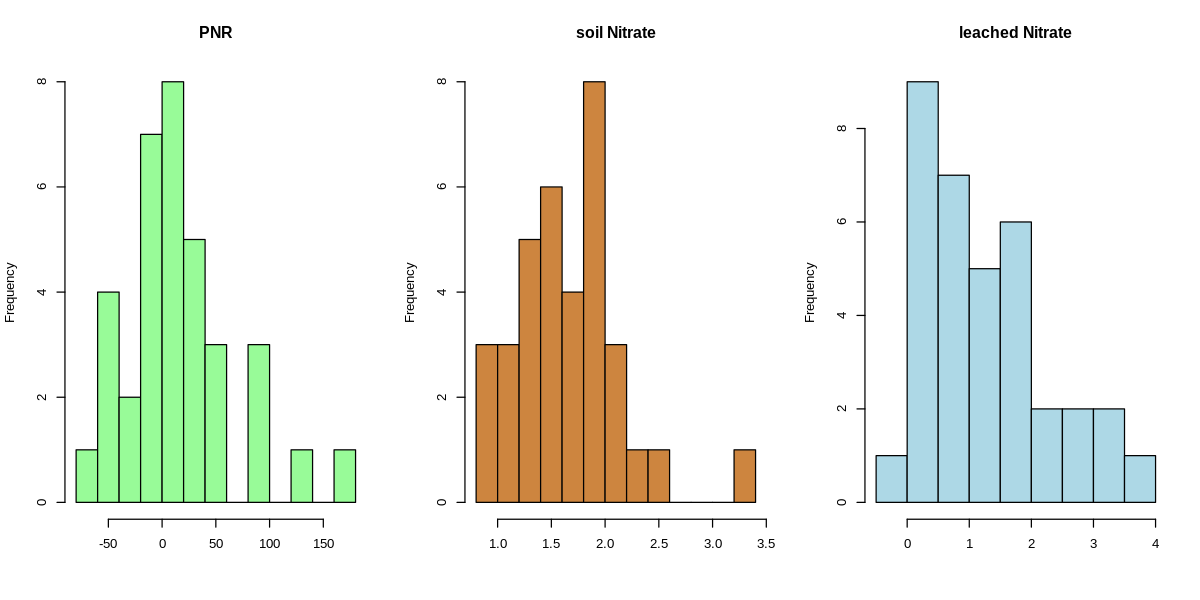

In [21]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,3))
hist(-BNI_avg,breaks = 10,main = "PNR",xlab = "",col="palegreen")
hist(log(soilN_avg+0.01),breaks = 10,main = "soil Nitrate",xlab = "",col = "tan3")
hist(log(resinN_avg+0.01),breaks = 10,main = "leached Nitrate",xlab = "",col = "lightblue")

In [23]:
#phenotype
pheno=data.frame(sample=names(BNI_avg),PNR=-BNI_avg,soilN =soilN_avg,resinN=resinN_avg)
rownames(pheno) = pheno[,1]
pheno1=data.frame(sample=names(BNI_avg),pheno=BNI_avg)
pheno2=data.frame(sample=names(soilN_avg),pheno=log(soilN_avg+0.01))
pheno3=data.frame(sample=names(resinN_avg),pheno=log(resinN_avg+0.01))

In [153]:
# load ML species phylogeny
nTre = read.tree("/workdir/sh2246/p_evolBNI/output/neutralTree/RAxML_bestTree.aln_4d_random1k.fasta.tree")
nTre.rooted = root(nTre,"REF")
length(nTre.rooted$tip.label)

[1] 38

In [154]:
nTre.rooted.renamed=nTre.rooted
merge_tab=data.frame(Sample=nTre.rooted$tip.label)
merge_tab=merge(merge_tab,metadata,by = "Sample")
merge_tab=merge_tab[!duplicated(merge_tab$Sample),]
rownames(merge_tab)=merge_tab$Sample
merge_tab=merge_tab[nTre.rooted$tip.label,]

nTre.rooted.renamed$tip.label[!is.na(merge_tab$Plant_ID)] = merge_tab$Plant_ID[!is.na(merge_tab$Plant_ID)]


In [155]:
K.neutral.ML = phyloK(nTre.rooted.renamed) 

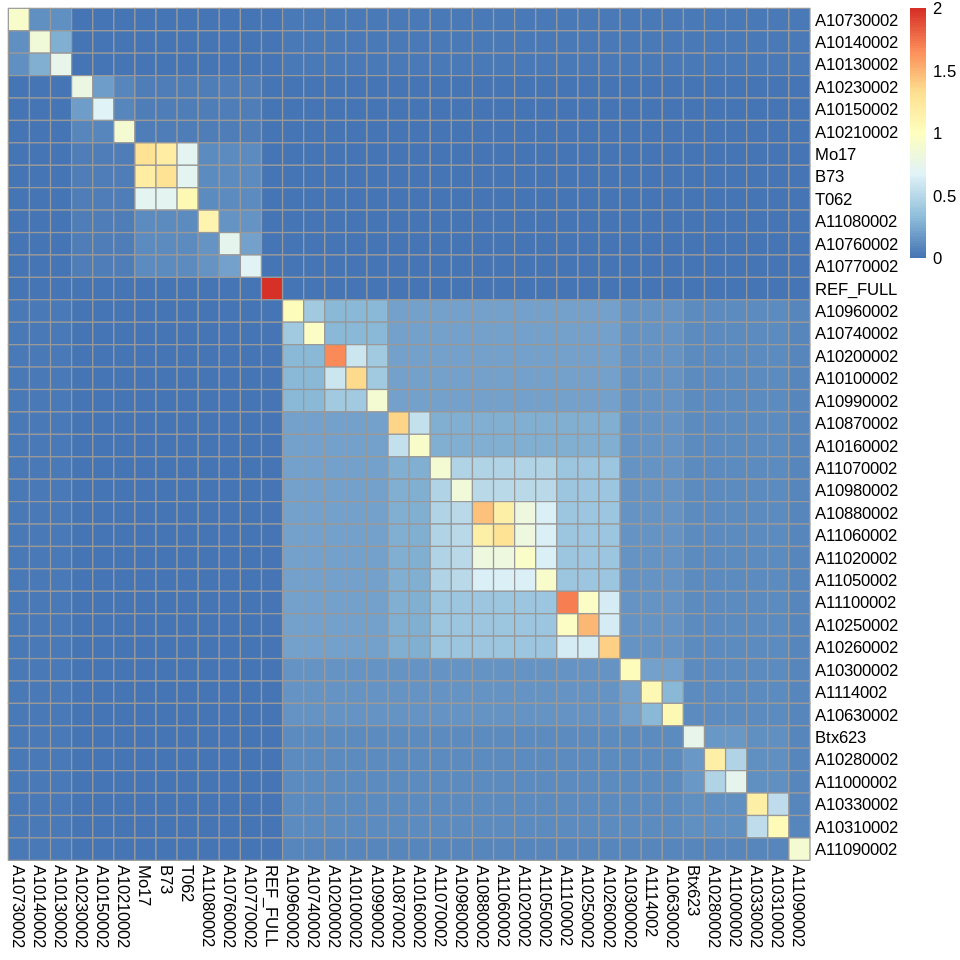

In [156]:
pheatmap(K.neutral.ML,cluster_rows = F,cluster_cols = F)

In [223]:
idx = intersect(pheno[,1],rownames(K.neutral.ML))
ModelI = BGLR(pheno[idx,2],response_type= "gaussian",nIter = 1e4,burnIn = 5e3,verbose = F,
               ETA=list(Kn=list(K =data.matrix(K.neutral.ML[idx,idx]),model="RKHS")))

In [265]:
# load ML neutral gene tree 
gnTre.flist = list.files("/workdir/sh2246/p_evolBNI/output/localNeutralTree/",pattern = "*bestTree*",full.names = "T")
gnTre.list = mclapply(gnTre.flist,function(x) read.tree(x),mc.cores = 40)
names(gnTre.list) = substr(strsplit2(gnTre.flist,"/")[,8],16,31)                    
gnTre.renamed = mclapply(gnTre.list,function(x) {
    x.renamed=x
    x.renamed$tip.label[grep("Pavag",x.renamed$tip.label)]="REF"
    x.renamed$tip.label = gsub(".final.contigs","",x.renamed$tip.label)
    x.renamed$tip.label = strsplit2(x.renamed$tip.label,"_")[,1]
    merge_tab=data.frame(Sample=x.renamed$tip.label)
    merge_tab=merge(merge_tab,metadata,by = "Sample")
    merge_tab=merge_tab[!duplicated(merge_tab$Sample),]
    rownames(merge_tab)=merge_tab$Sample
    merge_tab=merge_tab[x.renamed$tip.label,]

    x.renamed$tip.label[!is.na(merge_tab$Plant_ID)] = merge_tab$Plant_ID[!is.na(merge_tab$Plant_ID)]
    x.renamed = root(x.renamed,"REF_FULL")
    return(x.renamed)
},mc.cores = 20)
                     

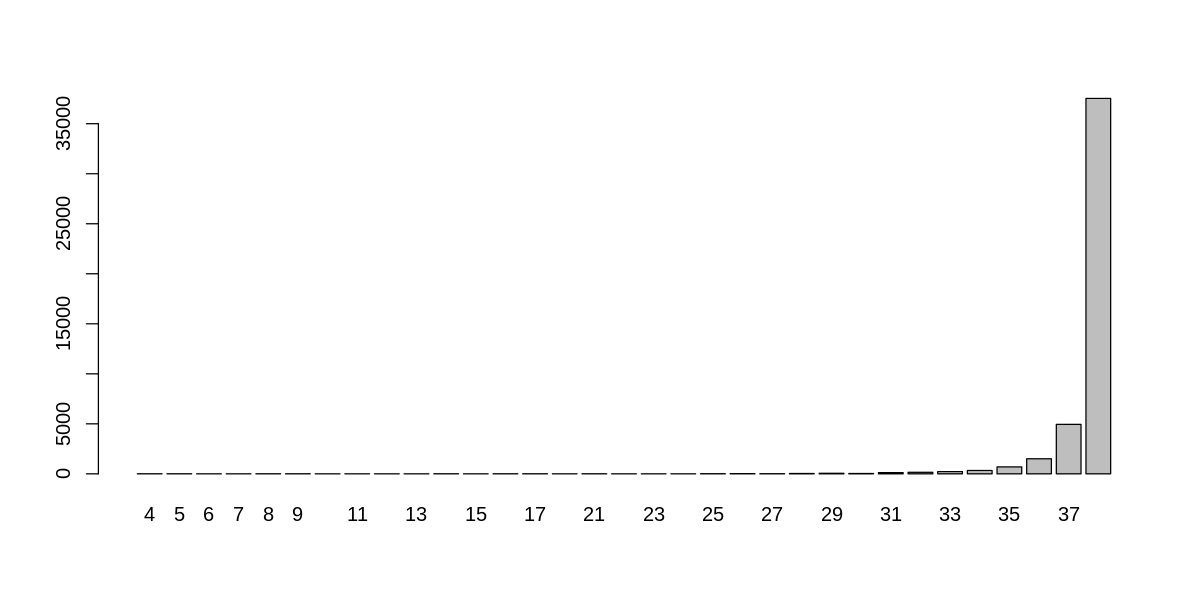

In [266]:
numTip.gnTre = sapply(gnTre.renamed,function(x) length(x$tip.label))
barplot(table(numTip.gnTre))                     

In [267]:
K.neutral.ML.list = mclapply(gnTre.renamed[numTip.gnTre >26],function(x) phyloK(x),mc.cores =30)
K.neutral.ML.list2 = mclapply(K.neutral.ML.list,function(x) {
    tmp = x
    missTaxa = setdiff(idx,rownames(x))
    tmp = cbind(tmp,matrix(rep(0,nrow(tmp)*length(missTaxa)),nrow = nrow(tmp),ncol = length(missTaxa)))
    tmp = rbind(tmp,matrix(rep(0,ncol(tmp)*length(missTaxa)),ncol = ncol(tmp),nrow = length(missTaxa)))
    rownames(tmp)[-(1:nrow(x))] = missTaxa
    colnames(tmp)[-(1:ncol(x))] = missTaxa
    return(tmp)
},mc.cores = 30)                          

In [268]:
length(gnTre.list)
length(gTre.list)

[1] 45784

[1] 40273

In [269]:
ModelI.list = mclapply(K.neutral.ML.list2,function(x){
#     idx = intersect(pheno[,1],rownames(x))
    ModelI = BGLR(pheno[idx,2],response_type= "gaussian",nIter = 1e4,burnIn = 5e3,verbose = F,
               ETA=list(Kn = list(K = data.matrix(x[idx,idx]),model="RKHS")))
    return(ModelI)               
},mc.cores = 40)


In [270]:
vae.baseline.list = mclapply(ModelI.list,function(x) (x$ETA$Kn$varU)/(x$ETA$Kn$varU+x$varE),
                    mc.cores = 30)

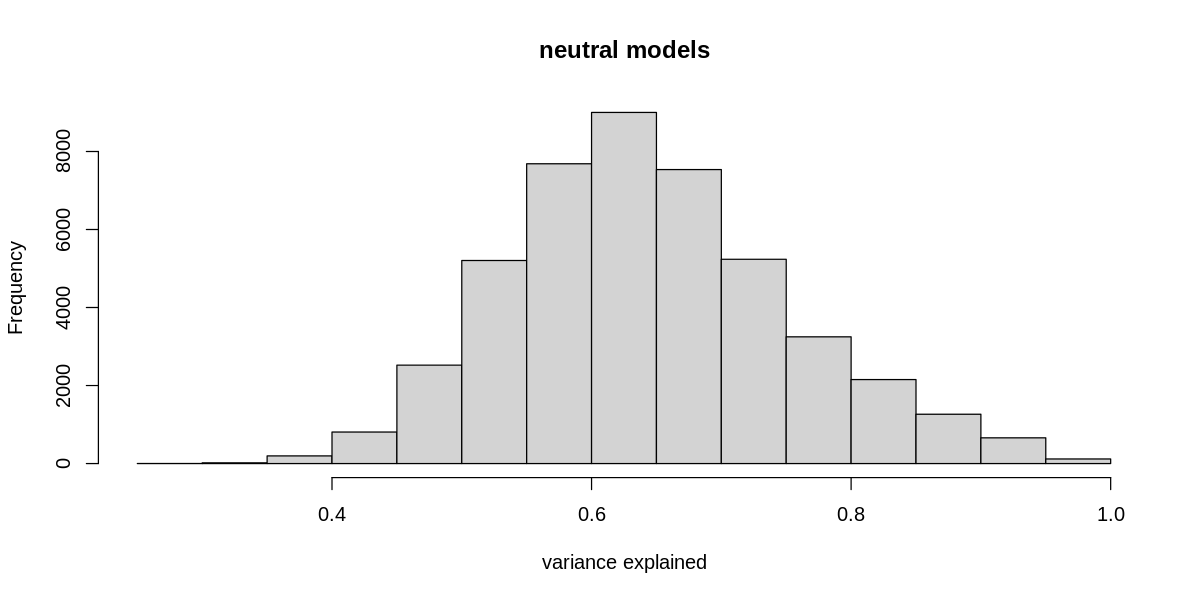

In [271]:
hist(unlist(vae.baseline.list),xlab = "variance explained",main = "neutral models")

In [224]:
vae.baseline = ModelI$ETA$Kn$varU/(ModelI$ETA$Kn$varU+ModelI$varE)
vae.baseline

[1] 0.5283432

In [198]:
# load ML gene tree 
gTre.flist = list.files("/workdir/sh2246/p_evolBNI/output/geneTree/",pattern = "*bestTree*",full.names = "T")
gTre.list = mclapply(gTre.flist,function(x) read.tree(x),mc.cores = 40)
names(gTre.list) = substr(strsplit2(gTre.flist,"/")[,8],16,31)                    
gTre.renamed = mclapply(gTre.list,function(x) {
    x.renamed=x
    x.renamed$tip.label[grep("Pavag",x.renamed$tip.label)]="REF"
    x.renamed$tip.label = gsub(".final.contigs","",x.renamed$tip.label)
    x.renamed$tip.label = strsplit2(x.renamed$tip.label,"_")[,1]
    merge_tab=data.frame(Sample=x.renamed$tip.label)
    merge_tab=merge(merge_tab,metadata,by = "Sample")
    merge_tab=merge_tab[!duplicated(merge_tab$Sample),]
    rownames(merge_tab)=merge_tab$Sample
    merge_tab=merge_tab[x.renamed$tip.label,]

    x.renamed$tip.label[!is.na(merge_tab$Plant_ID)] = merge_tab$Plant_ID[!is.na(merge_tab$Plant_ID)]
    x.renamed = root(x.renamed,"REF_FULL")
    return(x.renamed)
},mc.cores = 40)
                     

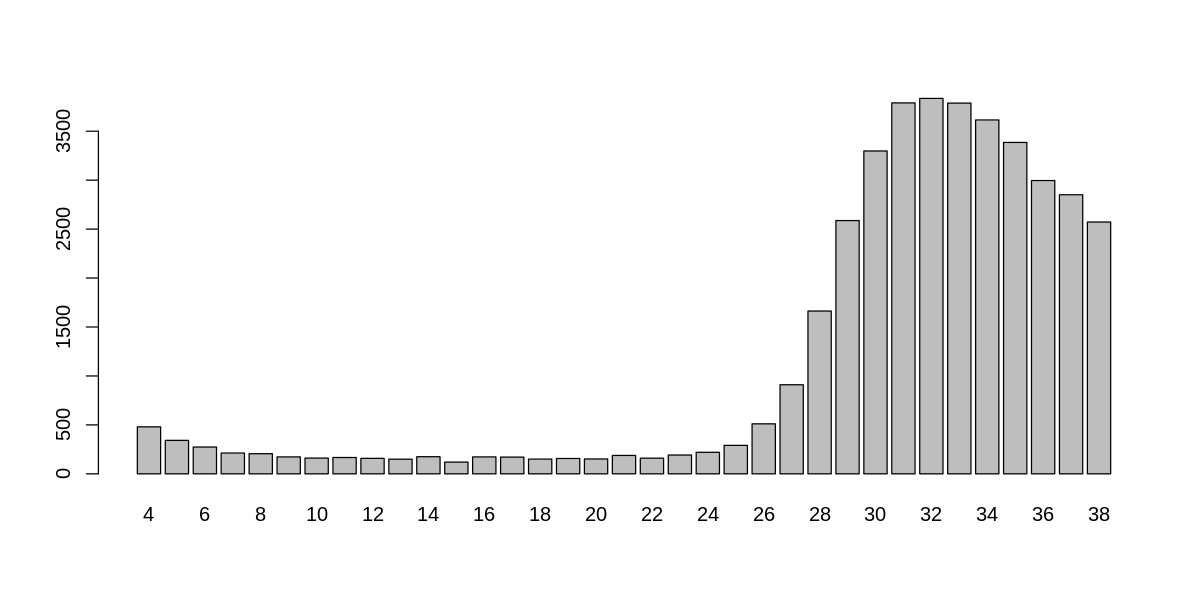

In [199]:
numTip.gTre = sapply(gTre.renamed,function(x) length(x$tip.label))
barplot(table(numTip.gTre))                     

In [200]:
K.gene.ML.list = mclapply(gTre.renamed[numTip.gTre >26],function(x) phyloK(x),mc.cores =40)

K.gene.ML.list2 = mclapply(K.gene.ML.list,function(x) {
    tmp = x
    missTaxa = setdiff(idx,rownames(x))
    tmp = cbind(tmp,matrix(rep(0,nrow(tmp)*length(missTaxa)),nrow = nrow(tmp),ncol = length(missTaxa)))
    tmp = rbind(tmp,matrix(rep(0,ncol(tmp)*length(missTaxa)),ncol = ncol(tmp),nrow = length(missTaxa)))
    rownames(tmp)[-(1:nrow(x))] = missTaxa
    colnames(tmp)[-(1:ncol(x))] = missTaxa
    return(tmp)
},mc.cores = 40)

In [ ]:
# # construct NJ phylogeny from alignment
# aln_flist = list.files("/workdir/sh2246/p_evolBNI/output/CDSMSAPerOG_v3_gs/",full.names = T)
# aln_list = mclapply(aln_flist,function(x) read.FASTA(x),mc.cores = 40)
# aln_ID = substr(strsplit2(aln_flist,"/")[,7],1,14)
# names(aln_list) = aln_ID

In [202]:
ModelII.list = mclapply(K.gene.ML.list2,function(x){
#     idx = intersect(pheno[,1],rownames(x))
    ModelII = BGLR(pheno[idx,2],response_type= "gaussian",nIter = 1e4,burnIn = 5e3,verbose = F,
               ETA=list(Kn = list(K = data.matrix(K.neutral.ML[idx,idx]),model="RKHS"), 
                        Kg = list(K = data.matrix(x[idx,idx]),model="RKHS")))
    return(ModelII)               
},mc.cores = 40)


In [203]:
vae.list = mclapply(ModelII.list,function(x) (x$ETA$Kn$varU+x$ETA$Kg$varU)/(x$ETA$Kn$varU+x$ETA$Kg$varU+x$varE),
                    mc.cores = 40)
LR.list = mclapply(ModelII.list,function(x) 2*(x$fit$logLikAtPostMean-ModelI$fit$logLikAtPostMean),mc.cores = 40)    

In [274]:
testGene = intersect(names(ModelI.list),names(K.gene.ML.list2))
ModelII.list2 = mclapply(testGene,function(x){
#     idx = intersect(pheno[,1],rownames(x))
    ModelII = BGLR(pheno[idx,2],response_type= "gaussian",nIter = 1e4,burnIn = 5e3,verbose = F,
               ETA=list(Kn = list(K = data.matrix(K.neutral.ML.list2[[x]][idx,idx]),model="RKHS"), 
                        Kg = list(K = data.matrix(K.gene.ML.list2[[x]][idx,idx]),model="RKHS")))
    return(ModelII)               
},mc.cores = 30)


In [275]:
names(ModelII.list2) = testGene

In [276]:
vae.list2 = mclapply(ModelII.list2,function(x) (x$ETA$Kn$varU+x$ETA$Kg$varU)/(x$ETA$Kn$varU+x$ETA$Kg$varU+x$varE),
                    mc.cores = 40)

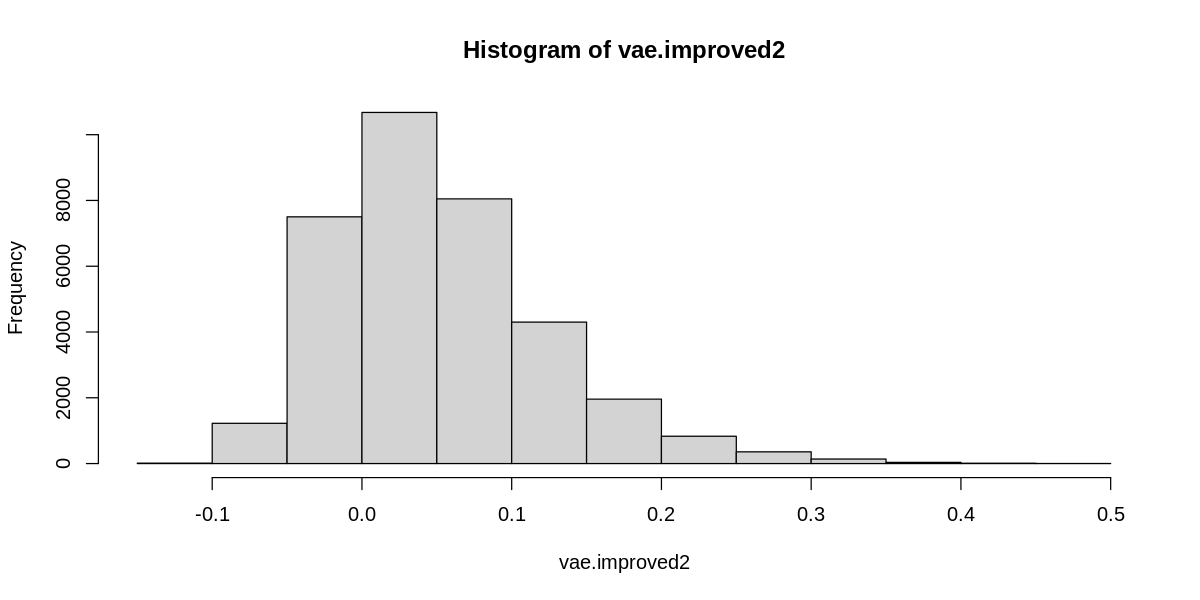

In [277]:
vae.improved2 = unlist(vae.list2[testGene]) - unlist(vae.baseline.list[testGene])
hist(vae.improved2)

In [278]:
LR.list2 = mclapply(testGene,function(x) 2*(ModelII.list2[[x]]$fit$logLikAtPostMean-ModelI.list[[x]]$fit$logLikAtPostMean),mc.cores = 40)

In [279]:
names(LR.list2) = testGene

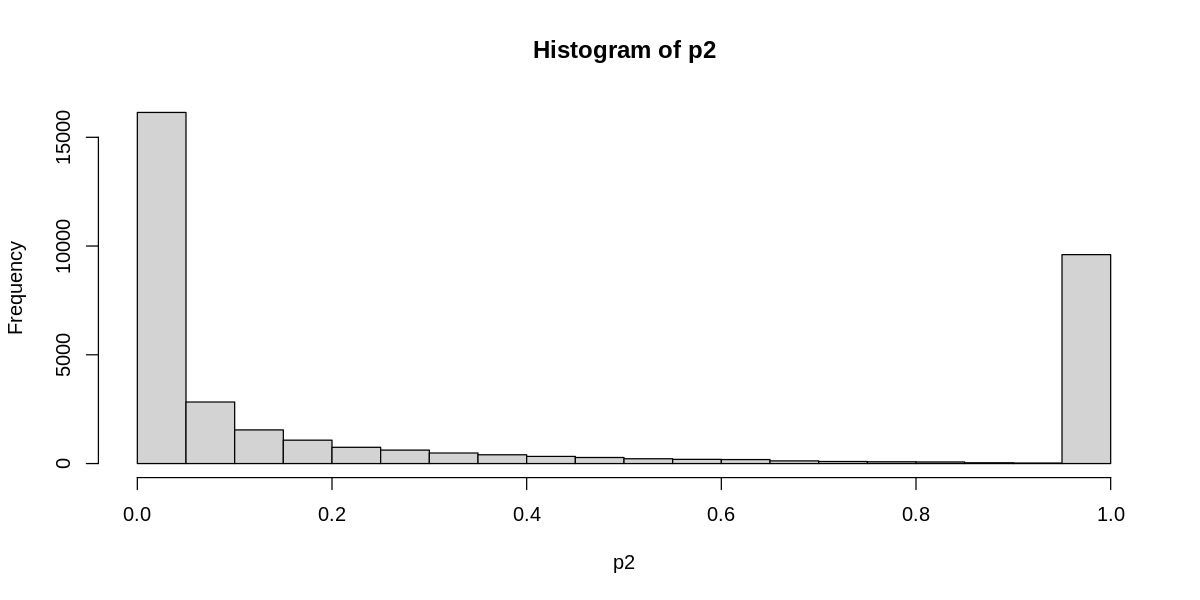

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.007422 0.071057 0.340903 1.000000 1.000000 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000925 0.0296837 0.1421070 0.3852346 1.0000000 1.0000000 

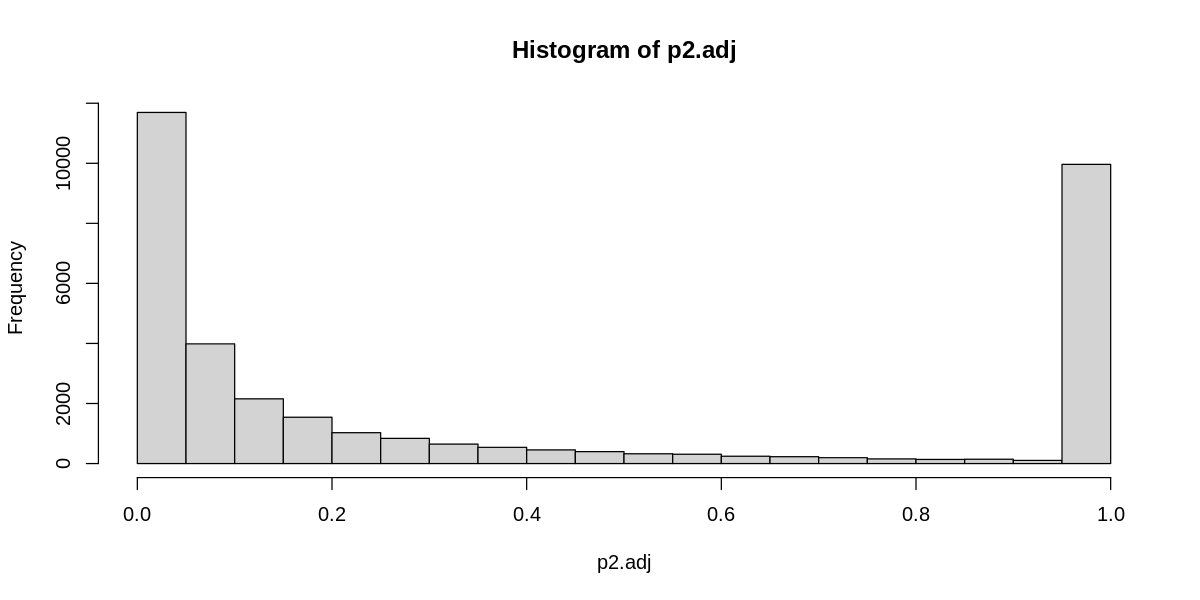

In [280]:
p2 = 1-pchisq(unlist(LR.list2),1)
p2.adj = p.adjust(p2,"BH")
hist(p2)
hist(p2.adj)
summary(p2)
summary(p2.adj)


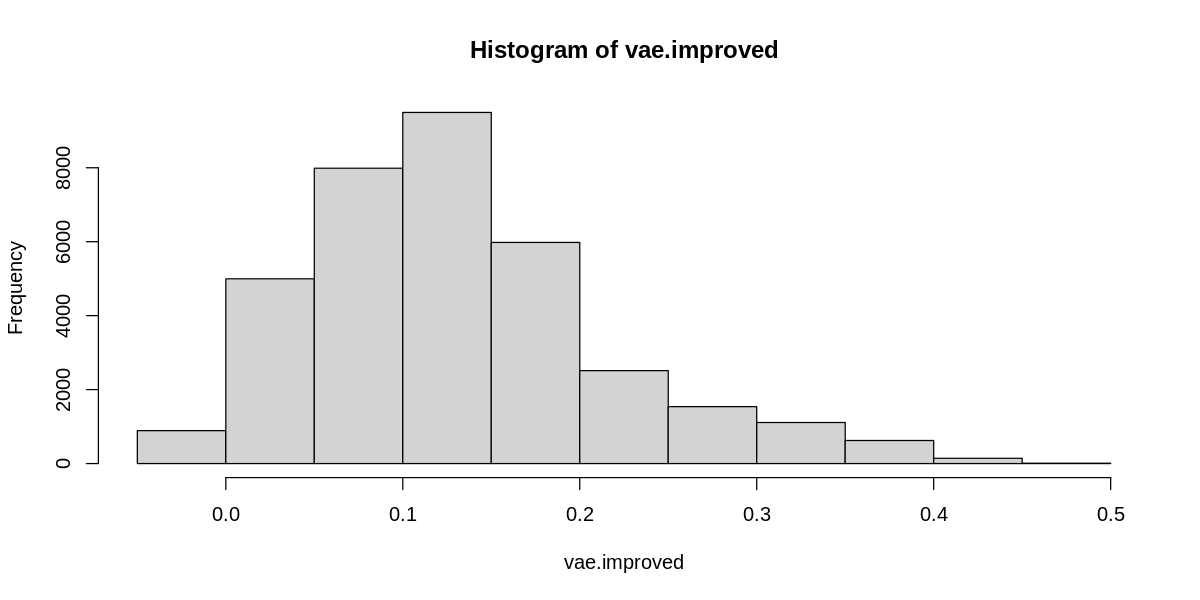

In [204]:
vae.improved = unlist(vae.list) - vae.baseline
hist(vae.improved)

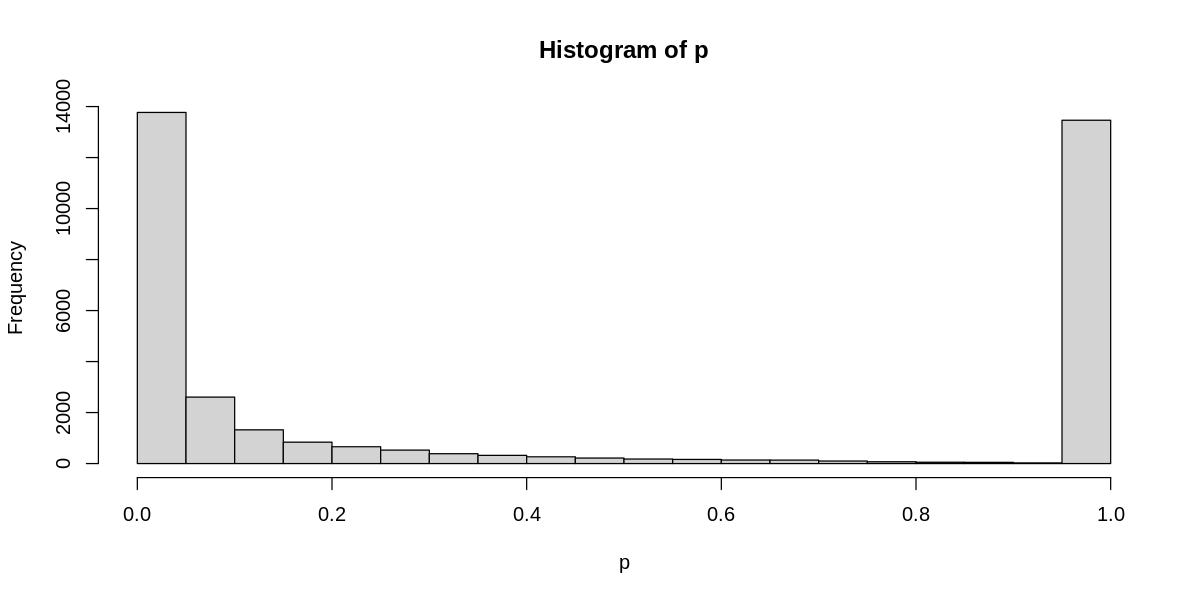

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000402 0.0167236 0.1471408 0.4397950 1.0000000 1.0000000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.04799 0.06689 0.29427 0.49999 1.00000 1.00000 

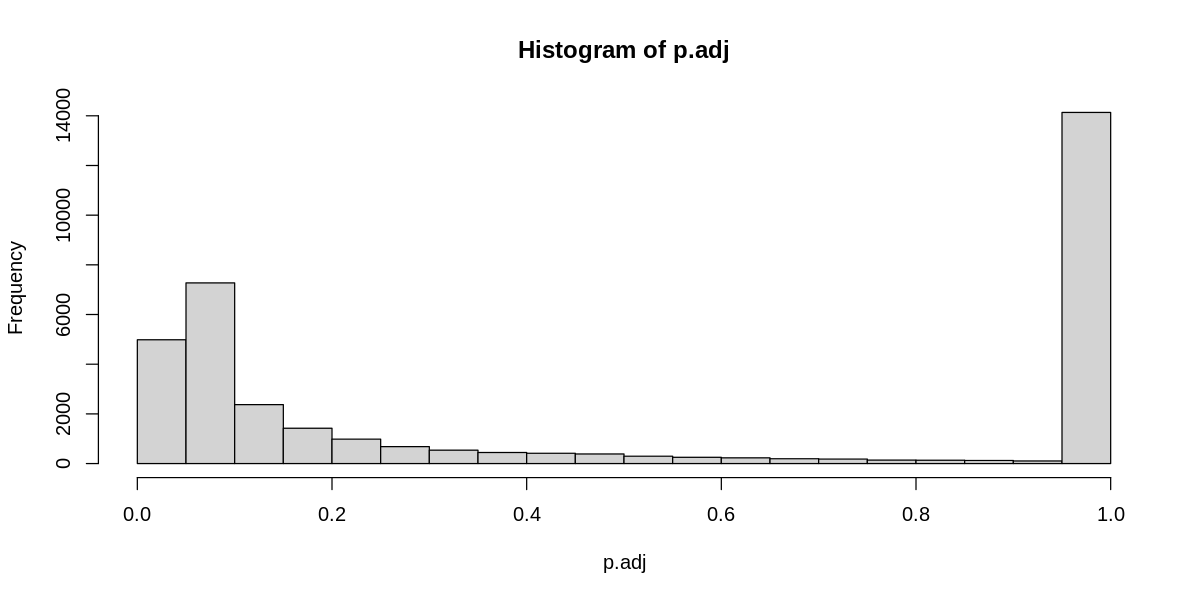

In [205]:
p = 1-pchisq(unlist(LR.list),1)
p.adj = p.adjust(p,"BH")
hist(p)
hist(p.adj)
summary(p)
summary(p.adj)


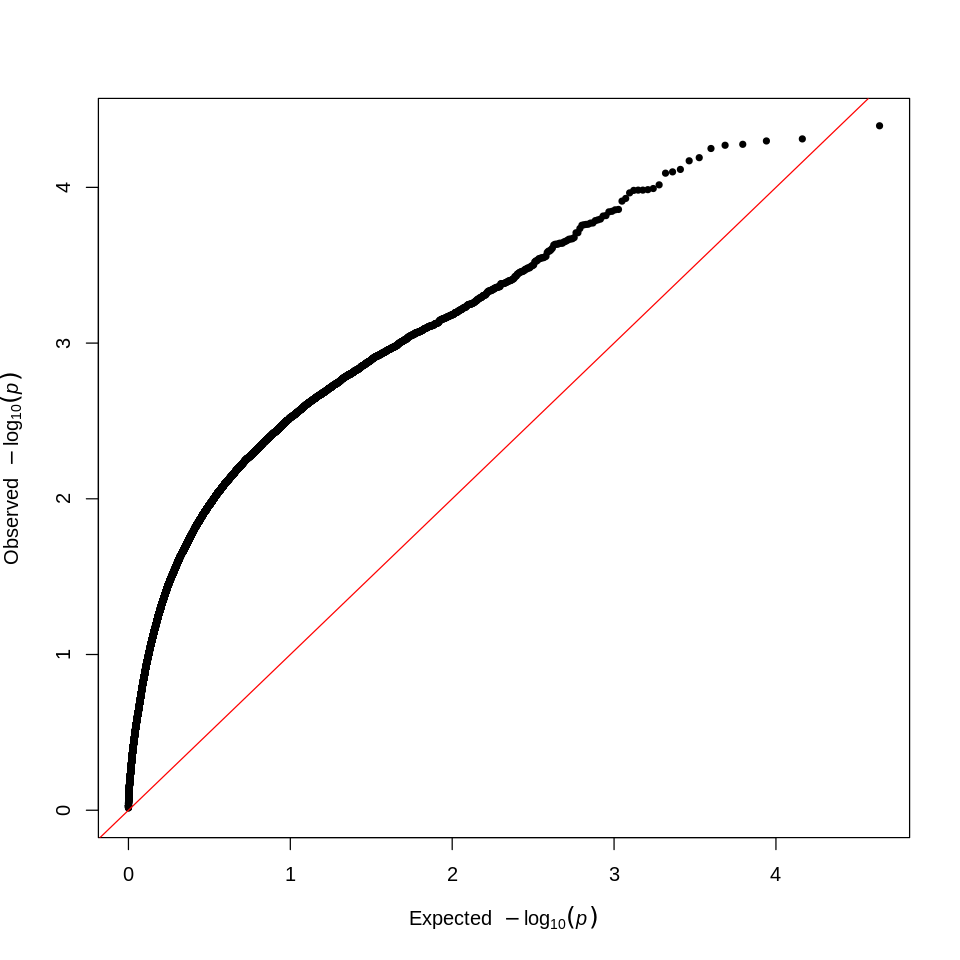

In [214]:
library(qqman)
options(repr.plot.width=8, repr.plot.height=8)
qq(p)

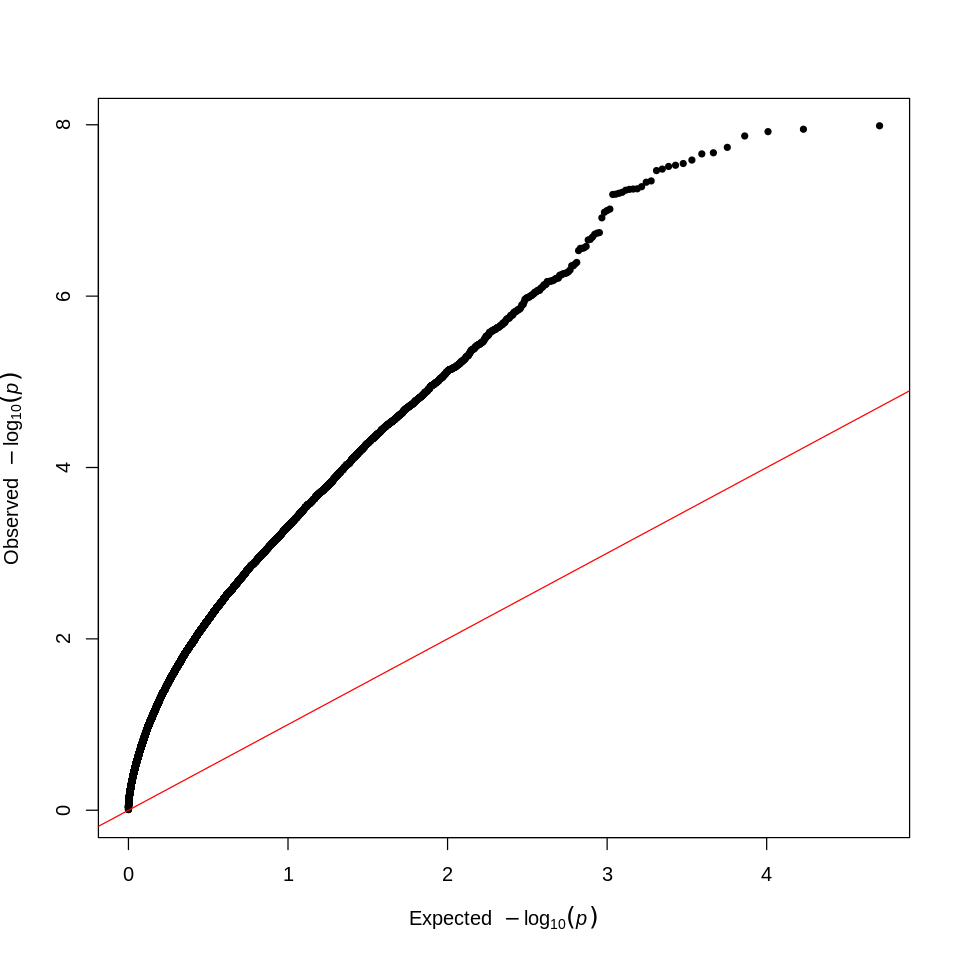

In [281]:
options(repr.plot.width=8, repr.plot.height=8)
qq(p2)

In [163]:
ModelI$fit$DIC
ModelII.list[[1]]$fit$DIC

[1] 334.5393

[1] 330.2328

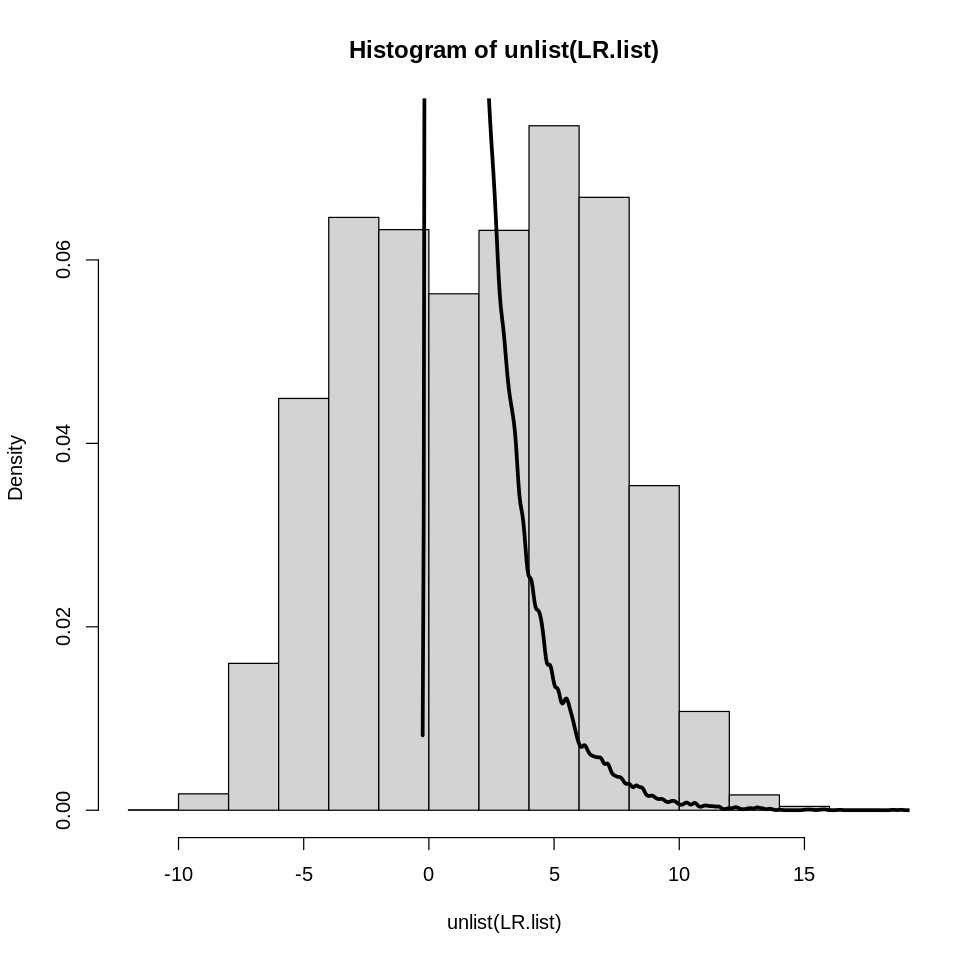

In [207]:
hist(unlist(LR.list),freq = F)
lines(density(rchisq(1e5,1)),lwd=3)

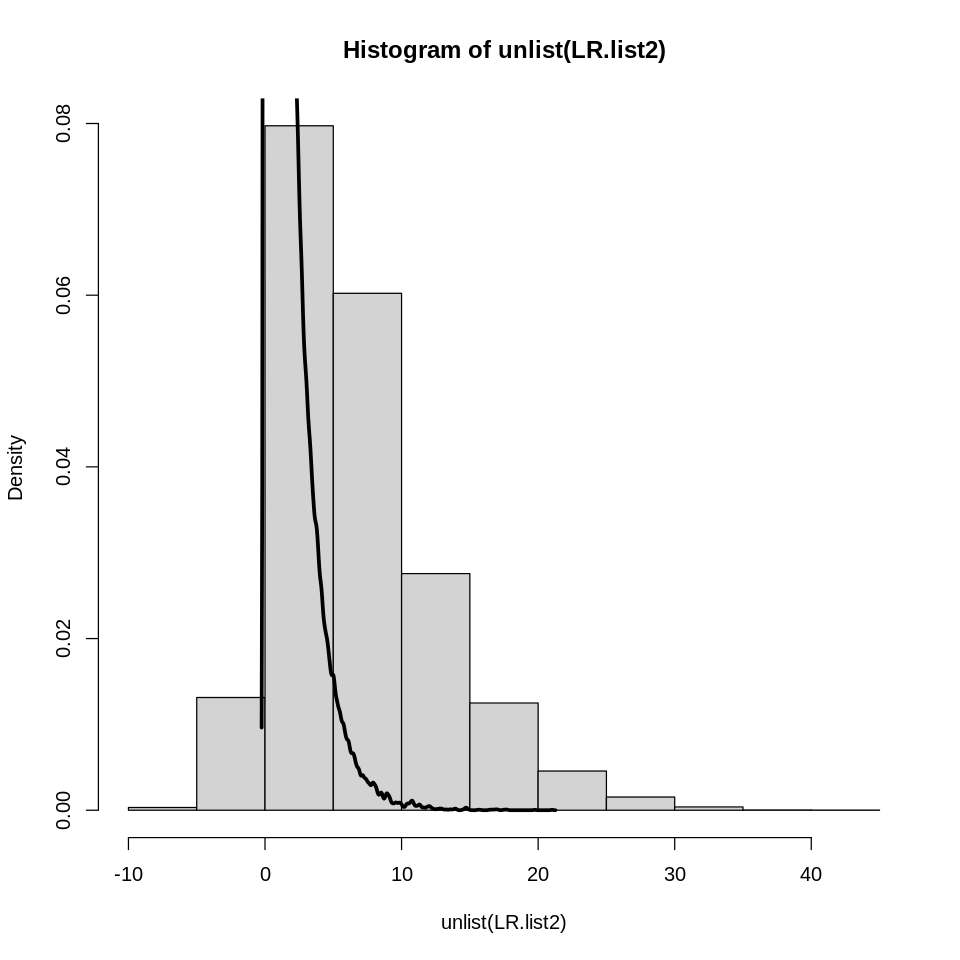

In [253]:
hist(unlist(LR.list2),freq = F)
lines(density(rchisq(1e5,1)),lwd=3)

[1] 0.2205562

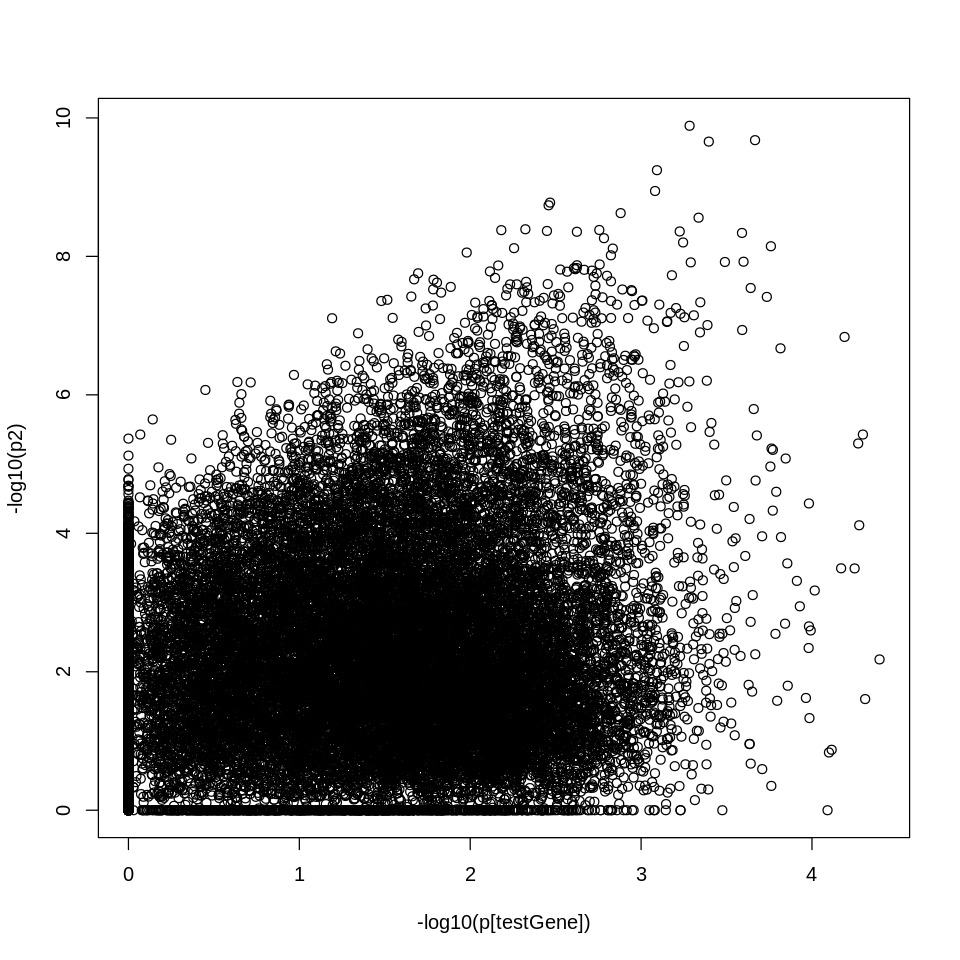

In [257]:
plot(-log10(p[testGene]),-log10(p2))
cor(p[testGene],p2)

In [135]:
dim(pheno)

[1] 35  4

In [177]:
gff=read.delim("/workdir/sh2246/p_evolBNI/data/Pvaginatum_672_v3.1.gene_exons_modified_sorted2.gff3",header = F)
gff_genePos=gff[gff$V3=="mRNA",]
rownames(gff_genePos)=gsub("ID=","",strsplit2(gff_genePos$V9,";")[,1])

In [178]:
head(gff_genePos)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
Pavag01G000100.1,Chr01,phytozomev13,mRNA,172695,173874,.,-,.,ID=Pavag01G000100.1;Name=Pavag01G000100.1;pacid=50356380;longest=1;Parent=Pavag01G000100
Pavag01G000200.1,Chr01,phytozomev13,mRNA,193720,198422,.,-,.,ID=Pavag01G000200.1;Name=Pavag01G000200.1;pacid=50353290;longest=1;Parent=Pavag01G000200
Pavag01G000200.2,Chr01,phytozomev13,mRNA,193720,198422,.,-,.,ID=Pavag01G000200.2;Name=Pavag01G000200.2;pacid=50353291;longest=0;Parent=Pavag01G000200
Pavag01G000300.1,Chr01,phytozomev13,mRNA,199474,200321,.,+,.,ID=Pavag01G000300.1;Name=Pavag01G000300.1;pacid=50358427;longest=1;Parent=Pavag01G000300
Pavag01G000300.2,Chr01,phytozomev13,mRNA,199474,200321,.,+,.,ID=Pavag01G000300.2;Name=Pavag01G000300.2;pacid=50358428;longest=0;Parent=Pavag01G000300
Pavag01G000400.1,Chr01,phytozomev13,mRNA,201734,202057,.,-,.,ID=Pavag01G000400.1;Name=Pavag01G000400.1;pacid=50353828;longest=1;Parent=Pavag01G000400


In [259]:
LRT_out = data.frame(Chr=as.numeric(gsub("Chr","",gff_genePos[names(p),]$V1)),
                     BP=gff_genePos[names(p),]$V4,Gene = names(p),
                     lnLR=unlist(LR.list),P=p)

In [263]:
LRT_out2 = data.frame(Chr=as.numeric(gsub("Chr","",gff_genePos[names(p2),]$V1)),
                     BP=gff_genePos[names(p2),]$V4,Gene = names(p2),
                     lnLR=unlist(LR.list2),P=p2)

In [209]:
head(LRT_out)

,Chr,BP,Gene,lnLR,P
,<dbl>,<int>,<chr>,<dbl>,<dbl>
1,1,172695,Pavag01G000100.1,9.086763,0.0025746619
2,1,193720,Pavag01G000200.1,-3.629150,1.0000000000
3,1,193720,Pavag01G000200.2,-4.077005,1.0000000000
4,1,237304,Pavag01G000500.1,7.172342,0.0074036042
5,1,237304,Pavag01G000500.2,11.169152,0.0008316862
6,1,237304,Pavag01G000500.3,8.030994,0.0045983609


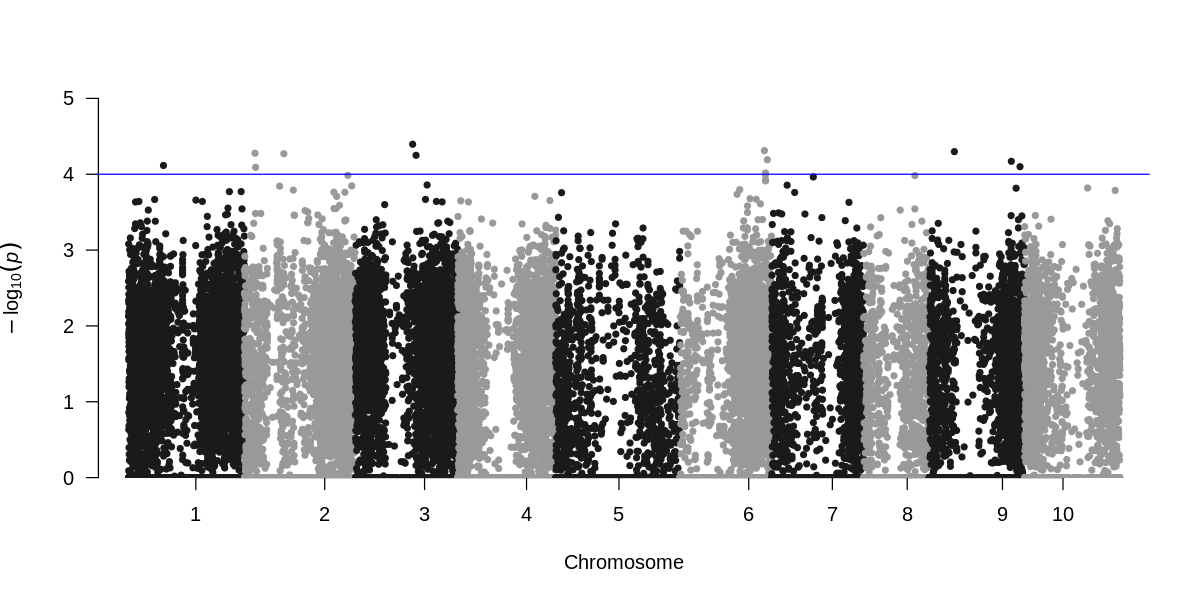

In [210]:
options(repr.plot.width=10, repr.plot.height=5)
manhattan(na.omit(LRT_out),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 4,genomewideline = F)


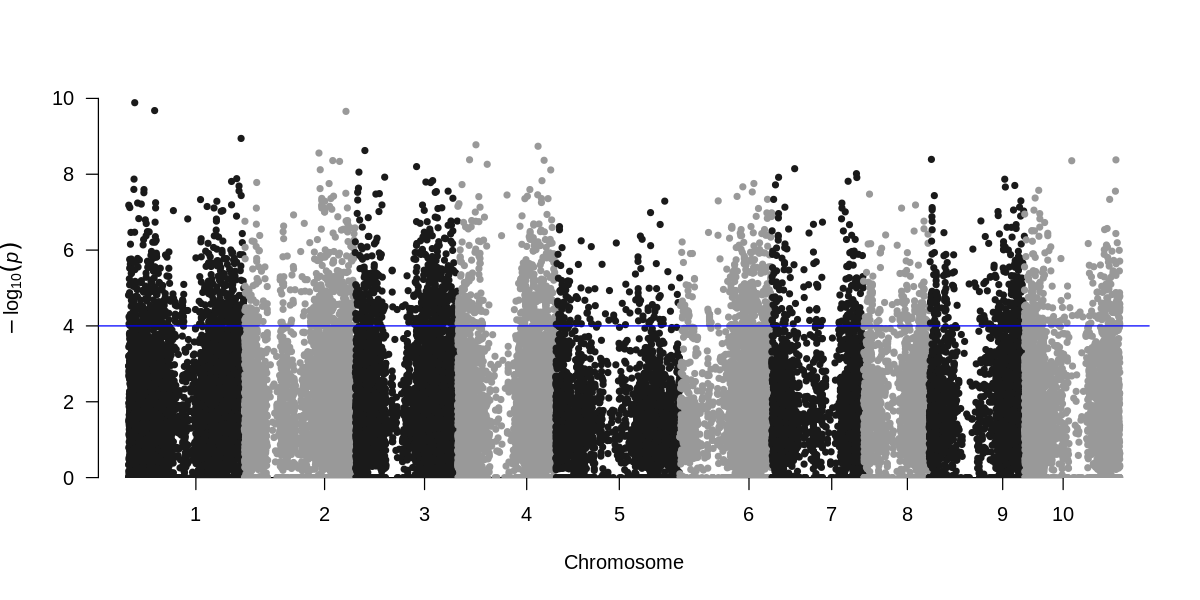

In [264]:
options(repr.plot.width=10, repr.plot.height=5)
manhattan(na.omit(LRT_out2),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 4,genomewideline = F)


In [211]:
head(sort(p),10)

Pavag03G169400.1 Pavag06G250300.1 Pavag09G085300.1 Pavag02G052500.1 
    4.022458e-05     4.883882e-05     5.035072e-05     5.290471e-05 
Pavag02G114600.1 Pavag03G176900.1 Pavag06G270300.1 Pavag09G184700.1 
    5.365347e-05     5.628070e-05     6.445973e-05     6.752606e-05 
Pavag01G205500.1 Pavag09G237100.1 
    7.668723e-05     7.952924e-05

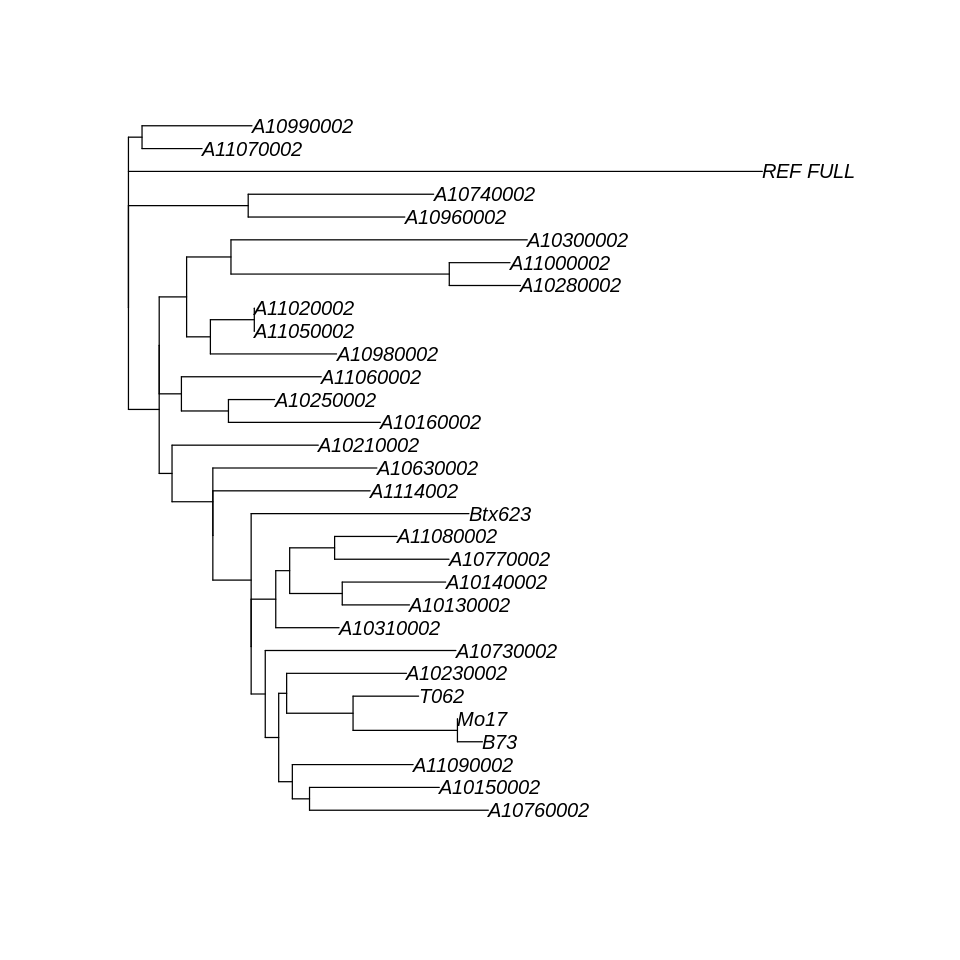

In [216]:
plot(gTre.renamed[["Pavag09G085300.1"]])